In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import LSTM, Embedding, TextVectorization
from tensorflow.keras.models import Model

2026-02-01 19:39:15.151151: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-01 19:39:15.183683: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-01 19:39:16.334505: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
!wget -nc https://lazyprogrammer.me/course_files/spam.csv

File ‘spam.csv’ already there; not retrieving.



In [3]:
!head spam.csv

v1,v2,,,
ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,
ham,Ok lar... Joking wif u oni...,,,
spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,,,
ham,U dun say so early hor... U c already then say...,,,
ham,"Nah I don't think he goes to usf, he lives around here though",,,
spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, �1.50 to rcv",,,
ham,Even my brother is not like to speak with me. They treat me like aids patent.,,,
ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune,,,
spam,WINNER!! As a valued network customer you have been selected to receivea �900 prize reward! To claim call 09061701461. Claim 

In [4]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# rename columns to something better
df.columns = ['labels', 'data']

In [9]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# create binary labels
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})
Y = df['b_labels'].values

In [11]:
# split up the data
df_train, df_test, Ytrain, Ytest = train_test_split(
    df['data'], Y, test_size=0.33)

In [12]:
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((df_train.values, Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((df_test.values, Ytest))

I0000 00:00:1769956758.114170 3122655 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3948 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [13]:
# Convert sentences to sequences
MAX_VOCAB_SIZE = 20000
vectorization = TextVectorization(max_tokens=MAX_VOCAB_SIZE)
vectorization.adapt(train_ds.map(lambda x, y: x))

2026-02-01 19:39:36.277357: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
# Shuffle and batch the dataset
train_ds = train_ds.shuffle(
    buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [15]:
# Get maximum sequence length so we can set "T"
T = 0
for x_batch, y_batch in train_ds:
  sequences = vectorization(x_batch)
  t = sequences.shape[1]
  if t > T:
    T = t
print(f'Maximum sequence length: {T}')

Maximum sequence length: 171


2026-02-01 19:39:37.205026: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
V = len(vectorization.get_vocabulary())

In [17]:
# Create the model

# We get to choose embedding dimensionality
D = 20

# Hidden state dimensionality
M = 15

# if string not specified, will get string -> float casting error
i = Input(shape=(1,), dtype=tf.string)
x = vectorization(i)
x = Embedding(V, D)(x)
x = LSTM(M, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [18]:
# Compile and fit
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


print('Training model...')
r = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Training model...
Epoch 1/10


2026-02-01 19:39:38.765441: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8495 - loss: 0.4757 - val_accuracy: 0.8722 - val_loss: 0.3585
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9253 - loss: 0.2390 - val_accuracy: 0.9804 - val_loss: 0.1199
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9791 - loss: 0.1096 - val_accuracy: 0.9766 - val_loss: 0.1024
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9716 - loss: 0.0952 - val_accuracy: 0.9810 - val_loss: 0.0865
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9914 - loss: 0.0523 - val_accuracy: 0.9750 - val_loss: 0.0761
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9946 - loss: 0.0328 - val_accuracy: 0.9810 - val_loss: 0.0639
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9976 - loss: 0.0228 - val_accuracy: 0.9804 - val_loss: 0.0656
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9981 - loss: 0.0188 - val_accuracy: 0.9799 - val_

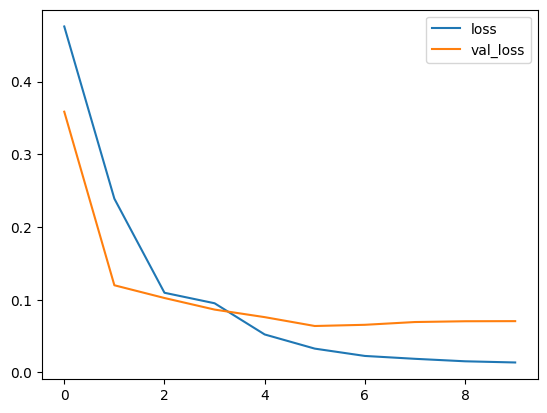

In [19]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

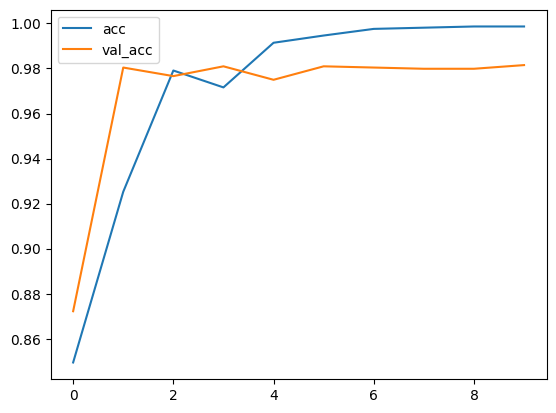

In [20]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

<Axes: >

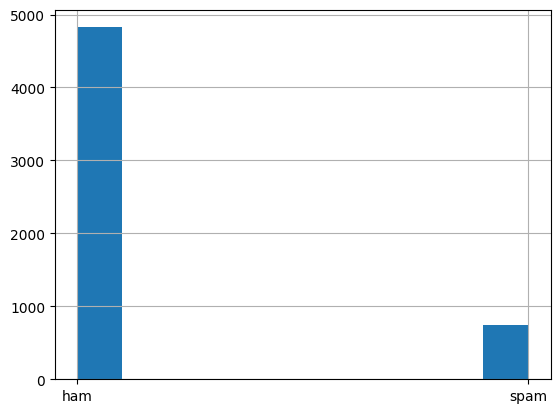

In [21]:
df['labels'].hist()

In [25]:
from sklearn.metrics import f1_score
pred_ds = tf.data.Dataset.from_tensor_slices(df_train.values)\
    .batch(32)

y_pred = model.predict(pred_ds)
y_pred = (y_pred.flatten() > 0.5).astype(int)

f1 = f1_score(Ytrain, y_pred)
print("Train F1:", f1)

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train F1: 0.9951028403525954


In [26]:
pred_ds_test = tf.data.Dataset.from_tensor_slices(df_test.values)\
    .batch(32)

y_pred_test = model.predict(pred_ds_test)
y_pred_test = (y_pred_test.flatten() > 0.5).astype(int)

f1 = f1_score(Ytest, y_pred_test)
print("Test F1:", f1)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test F1: 0.9285714285714286


In [27]:
# What if we pre-convert strings to ints?
train_ints = vectorization(df_train.values)
test_ints = vectorization(df_test.values)

In [28]:
train_ints.shape

TensorShape([3733, 171])

In [29]:
test_ints.shape

TensorShape([1839, 115])

In [30]:
# notice how there's lots of padding
train_ints[:5]

<tf.Tensor: shape=(5, 171), dtype=int64, numpy=
array([[ 272,   39,  406,   47,    8,   88,   18,    2,   47,    2, 3884,
         482,   20,    4,   28,   92,   62,  180,    2,  503,    9,   98,
          25,  537,   47,    2,  426,  223,  371, 1113,   29,  111,  203,
           9,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,   

In [31]:
# create tf datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_ints, Ytrain))
test_ds = tf.data.Dataset.from_tensor_slices((test_ints, Ytest))

In [32]:
# shuffle and batch the dataset
train_ds = train_ds.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [33]:
# Create the model

# We get to choose embedding dimensionality
D = 20

# Hidden state dimensionality
M = 15

# if string not specified, will get string -> float casting error
i = Input(shape=(None,))
x = Embedding(V, D)(i)
x = LSTM(M, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [34]:
# Compile and fit
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Training model...')
r = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Training model...
Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8556 - loss: 0.4270 - val_accuracy: 0.8722 - val_loss: 0.3239
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8923 - loss: 0.2359 - val_accuracy: 0.9723 - val_loss: 0.1484
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9839 - loss: 0.1093 - val_accuracy: 0.9755 - val_loss: 0.1047
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9885 - loss: 0.0724 - val_accuracy: 0.9799 - val_loss: 0.0916
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9906 - loss: 0.0564 - val_accuracy: 0.9831 - val_loss: 0.0776
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9938 - loss: 0.0391 - val_accuracy: 0.9842 - val_loss: 0.0704
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9962 - loss: 0.0284 - val_accuracy: 0.9766 - val_loss: 0.0922
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9973 - loss: 0.0222 